In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/Crop_recommendation.csv')
df.shape

(2200, 8)

In [4]:
df.sample(10)

,N,P,K,temperature,humidity,ph,rainfall,label
327,24,80,22,16.711706,19.176514,5.635994,96.772858,kidneybeans
1134,5,16,31,35.960546,48.696778,4.555689,98.006442,mango
1107,18,17,31,31.745921,45.161279,5.667508,93.754416,mango
2188,107,31,31,23.171246,52.978412,6.766184,153.120164,coffee
1622,8,7,10,28.262049,91.983174,6.929216,105.213226,orange
997,13,17,45,21.254336,92.650589,7.159521,106.278467,pomegranate
1533,10,141,201,22.126594,90.978183,6.386021,104.541228,apple
563,28,57,17,30.477577,61.582453,9.416003,61.866339,mothbeans
736,21,78,19,27.161591,66.760172,6.920090,69.851123,blackgram
1793,58,55,47,26.053758,93.691117,6.742490,240.686390,papaya


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [6]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['label'].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df.drop('label',axis=1),df['label'],test_size=0.15,random_state=42)
x_train.shape

(1870, 7)

In [11]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
x_train = ss.fit_transform(x_train)
x_test = ss.transform(x_test)

In [12]:
x_train

array([[-0.53184825, -0.0105193 , -0.62762693, ...,  0.64673019,
        -0.02611259, -0.98598671],
       [-0.39753588, -0.79494915, -0.43155577, ...,  1.10251549,
        -0.28081133,  1.23762517],
       [ 1.53656222, -0.22171195, -0.60801981, ...,  0.60376492,
         0.59313715, -0.68827478],
       ...,
       [-1.06909772, -0.52341574, -0.33352019, ..., -0.90891318,
         0.00411801, -0.05172865],
       [-1.06909772,  2.13157761,  3.05851087, ...,  0.38391102,
        -0.14328743, -0.57309011],
       [-0.50498577,  0.74374018, -0.50998423, ..., -0.42554785,
         0.68962425, -0.89812866]])

In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [14]:
y_train

array([14,  4,  6, ..., 12,  7, 10])

In [15]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Dropout

In [16]:
model = Sequential()
model.add(Dense(64,activation='relu',input_dim=7))
model.add(Dropout(0.2))
model.add(Dense(32,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(22,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 22)             │           726 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,318 (12.96 KB)

 Trainable params: 3,318 (12.96 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [22]:
history = model.fit(x_train, y_train,validation_split=0.1,epochs=50,batch_size=16,verbose=1)

Epoch 1/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9614 - loss: 0.1120 - val_accuracy: 0.9733 - val_loss: 0.0608
Epoch 2/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9596 - loss: 0.1198 - val_accuracy: 0.9733 - val_loss: 0.0655
Epoch 3/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9548 - loss: 0.1206 - val_accuracy: 0.9840 - val_loss: 0.0585
Epoch 4/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9620 - loss: 0.1090 - val_accuracy: 0.9786 - val_loss: 0.0626
Epoch 5/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9584 - loss: 0.1143 - val_accuracy: 0.9840 - val_loss: 0.0545
Epoch 6/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9638 - loss: 0.1017 - val_accuracy: 0.9733 - val_loss: 0.0610
Epoch 7/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9590 - loss: 0.1118 - val_accuracy: 0.9679 - val_loss: 0.0886
Epoch 8/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9495 - loss: 0.1262 - val_accuracy:

In [23]:
from sklearn.metrics import accuracy_score

y_pred = np.argmax(model.predict(x_test),axis=1)
accuracy_score(y_test,y_pred)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


0.9757575757575757

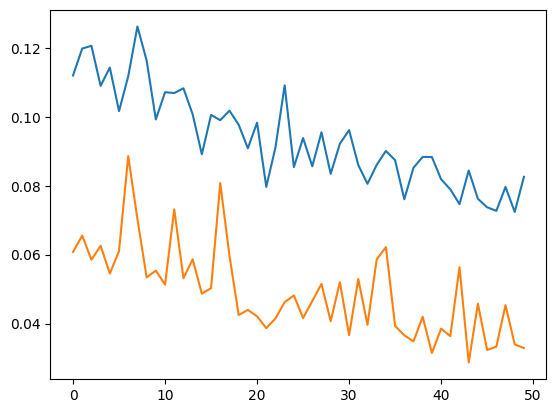

In [27]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

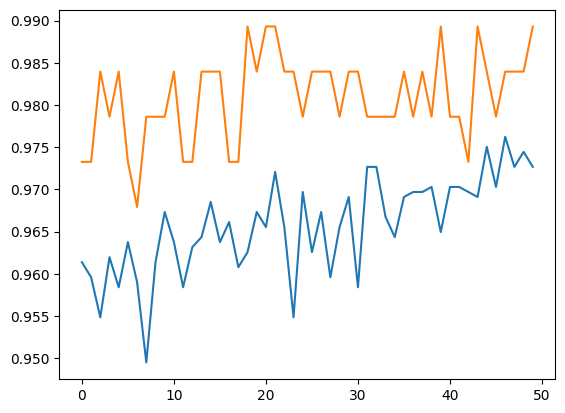

In [28]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [29]:
from keras.models import model_from_json
class CropPipeline:
    def __init__(self, model, scaler, label_encoder):
        self.model_config = model.to_json()
        self.model_weights = model.get_weights()
        self.scaler = scaler
        self.label_encoder = label_encoder

    def predict(self, X):
        model = model_from_json(self.model_config)
        model.set_weights(self.model_weights)
        X_scaled = self.scaler.transform(X)
        probs = model.predict(X_scaled)
        idx = probs.argmax(axis=1)
        return self.label_encoder.inverse_transform(idx)

In [30]:
import joblib
pipeline = CropPipeline(model=model, scaler=ss, label_encoder=le)
joblib.dump(pipeline, 'crop_pipeline.pkl')

['crop_pipeline.pkl']

In [31]:
test_pipeline = joblib.load('crop_pipeline.pkl')
result = test_pipeline.predict([[90, 42, 43, 20.87, 82.0, 6.5, 202.9]])
print(result)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
['rice']
